In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [17]:
df = pd.read_csv(r"train.csv")

In [18]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [19]:
df.shape

(9800, 18)

In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y", errors='coerce')
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y", errors='coerce')

In [29]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [33]:
# Custom function using comparison operators instead of list brackets
def get_season(month):
    if month == 12 or month == 1 or month == 2:
        return 'Winter'
    elif month >= 3 and month <= 5:
        return 'Spring'
    elif month >= 6 and month <= 8:
        return 'Summer'
    else:
        return 'Autumn/Fall'

df["Season"] = df["Month"].apply(get_season)


In [34]:
# 4. DEEP EXPLORATION (MISSING VALUES, DUPLICATES, & TYPES)
# =====================================================================
print("--- DATA HEALTH CHECK ---")
print(f"Missing values in Order Date: {df['Order Date'].isna().sum()}")
print(f"Duplicate rows count: {df.duplicated().sum()}")
print(df.dtypes)
print("-" * 30 + "\n")

--- DATA HEALTH CHECK ---
Missing values in Order Date: 0
Duplicate rows count: 0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week Number              UInt32
Day of Week              object
Quarter                   int32
Season                   object
dtype: object
------------------------------



In [35]:
# 5. AGGREGATE RESAMPLING (WEEKLY & MONTHLY)
# Set 'Order Date' as index for easy time-series resampling
ts_df = df.set_index("Order Date")
# Weekly Aggregated Sales
weekly_sales = ts_df["Sales"].resample("W").sum().reset_index()
# Monthly Aggregated Sales
monthly_sales = ts_df["Sales"].resample("MS").sum().reset_index() # MS = Month Start

In [36]:
category_revenue = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("--- Question 1: Revenue by Category ---")
print(category_revenue)
print(f"\nWinner: {category_revenue.index[0]} with total sales of ${category_revenue.iloc[0]:,.2f}")


--- Question 1: Revenue by Category ---
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

Winner: Technology with total sales of $827,455.87


In [37]:
region_yearly = df.groupby(["Region", "Year"])["Sales"].sum().unstack(level=0)
region_growth = region_yearly.pct_change().dropna() * 100

print("--- Question 2: YoY Sales Growth (%) by Region ---")
print(region_growth.round(2))
# Note: Look for the region whose growth percentages stay positive and steady across all years.


--- Question 2: YoY Sales Growth (%) by Region ---
Region  Central   East  South   West
Year                                
2016      -0.48  20.03 -32.21  -8.36
2017      42.22  16.50  33.48  36.47
2018      -2.78  17.71  30.61  35.98


In [38]:
# Calculate shipping days duration
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

overall_avg = df["Shipping Days"].mean()
regional_avg = df.groupby("Region")["Shipping Days"].mean().sort_values()

print("--- Question 3: Shipping Times ---")
print(f"Overall Average Shipping Time: {overall_avg:.2f} days\n")
print("Average Shipping Time by Region:")
print(regional_avg.round(2))


--- Question 3: Shipping Times ---
Overall Average Shipping Time: 3.96 days

Average Shipping Time by Region:
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: Shipping Days, dtype: float64


In [40]:
# Group by Year and Month to see repetitive patterns
seasonal_matrix = df.groupby(["Year", "Month Name"])["Sales"].sum().unstack(level=0)
# Reorder months chronologically
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
seasonal_matrix = seasonal_matrix.reindex(months_order)

print("--- Question 4: Monthly Sales Matrix (Check for Spikes) ---")

# Simply remove the print() wrapper around the matrix variable
seasonal_matrix.reindex(months_order).style.format("${:,.0f}")


--- Question 4: Monthly Sales Matrix (Check for Spikes) ---


Year,2015,2016,2017,2018
Month Name,,,,
January,"$14,206","$18,067","$18,542","$43,476"
February,"$4,520","$11,951","$22,979","$19,921"
March,"$55,206","$32,339","$51,165","$58,863"
April,"$27,907","$34,154","$38,680","$35,542"
May,"$23,644","$29,960","$56,657","$43,826"
June,"$34,323","$23,599","$39,724","$48,191"
July,"$33,782","$28,608","$38,321","$44,825"
August,"$27,118","$36,818","$30,542","$62,838"
September,"$81,624","$63,134","$69,193","$86,153"


In [41]:
!pip install statsmodels

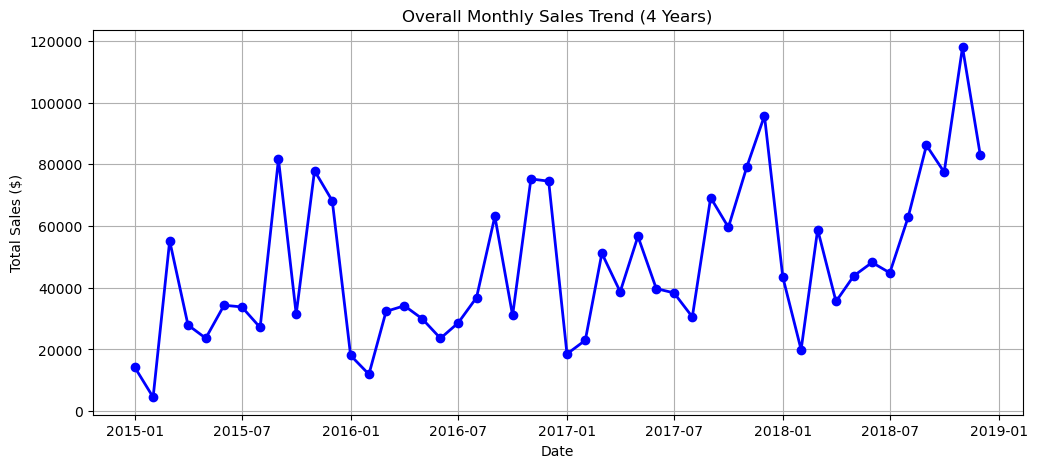

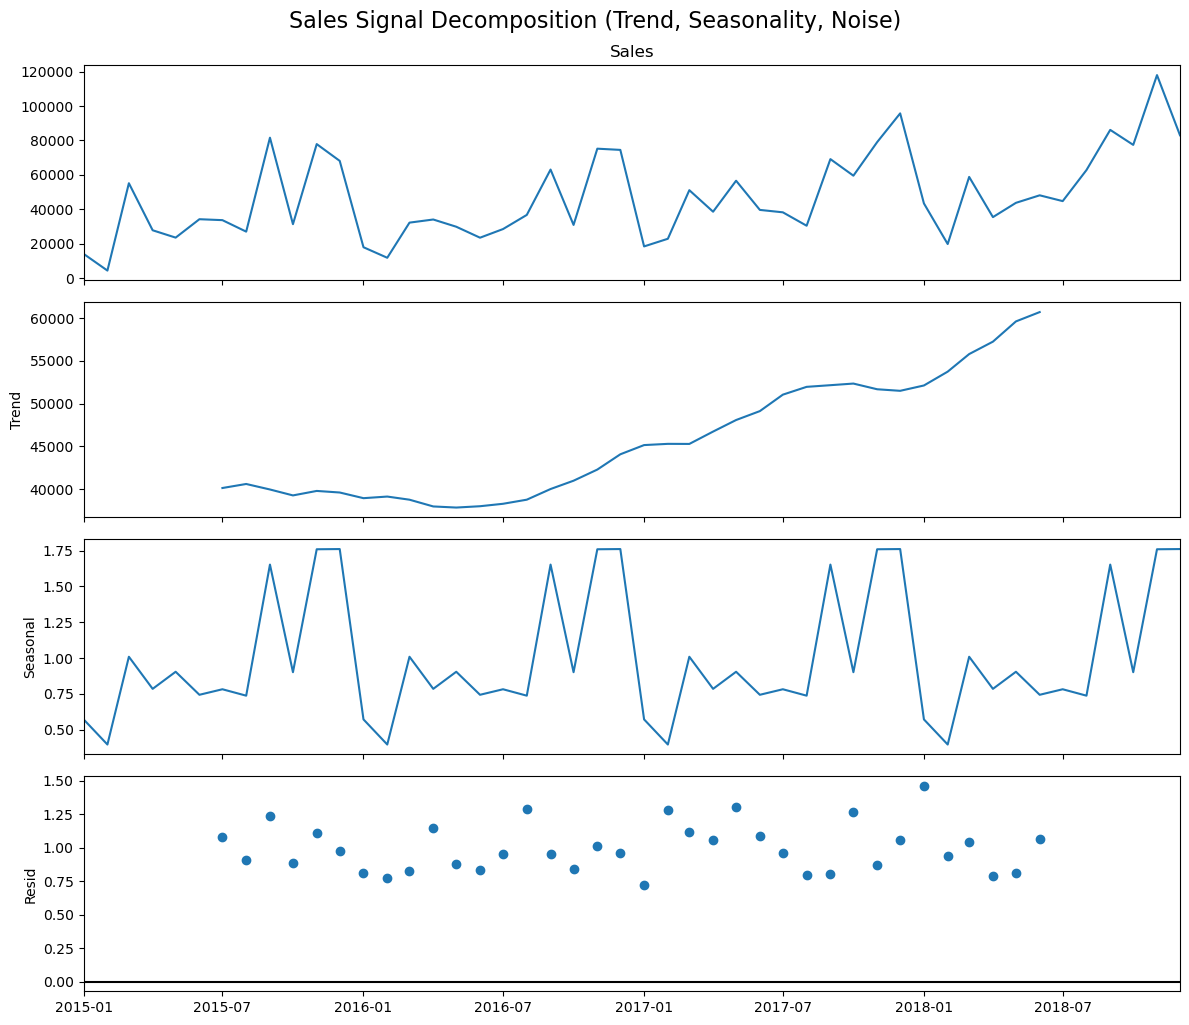

--- Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -4.4161
p-value: 0.0003

Result: Data is already stationary. No differencing needed.


In [42]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
# 1. Prepare continuous monthly data series
monthly_series = ts_df["Sales"].resample("MS").sum()
# 2. Plot overall monthly sales trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_series, marker='o', color='b', linewidth=2)
plt.title("Overall Monthly Sales Trend (4 Years)")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.show()
# 3. Apply Time Series Decomposition (using Multiplicative due to growing spikes)
decomposition = seasonal_decompose(monthly_series, model='multiplicative', period=12)
# 4. Plot all 4 components clearly on one figure
plt.rcParams['figure.figsize'] = (12, 10)
fig = decomposition.plot()
plt.suptitle("Sales Signal Decomposition (Trend, Seasonality, Noise)", fontsize=16, y=1.02)
plt.show()
# 5. Check for stationarity using the Augmented Dickey-Fuller (ADF) Test
print("--- Augmented Dickey-Fuller (ADF) Test ---")
result = adfuller(monthly_series)
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
# 6. Apply differencing if series is non-stationary (p-value > 0.05)
if result[1] > 0.05:
    print("\nResult: Data is non-stationary. Applying first-order differencing...")
    diff_series = monthly_series.diff().dropna()
    # Re-test stationary status
    diff_result = adfuller(diff_series)
    print(f"New ADF Statistic after differencing: {diff_result[0]:.4f}")
    print(f"New p-value: {diff_result[1]:.4f}")
else:
    print("\nResult: Data is already stationary. No differencing needed.")

In [43]:
!pip install prophet xgboost

  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.1 MB 1.6 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/12.1 MB 1.6 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/12.1 MB 1.6 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/12.1 MB 1.6 MB/

# Model 1 : SARIMA

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


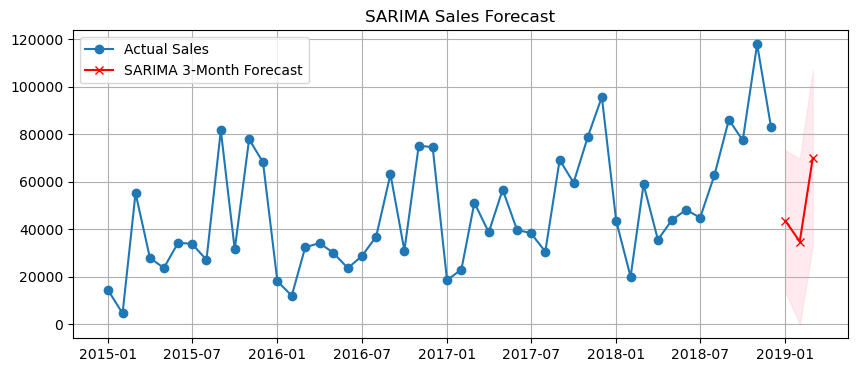

In [48]:
# Ensure data is continuous monthly
monthly_series = ts_df["Sales"].resample("MS").sum()

# Fit SARIMA (p=1, d=1, q=1) x (P=1, D=1, Q=1, s=12)
model_sarima = SARIMAX(monthly_series, order=(1,1,1), seasonal_order=(1,1,1,12))
results_sarima = model_sarima.fit(disp=False)

# Forecast next 3 months using the correct get_forecast() method
forecast_steps = 3
sarima_pred = results_sarima.get_forecast(steps=forecast_steps)
sarima_mean = sarima_pred.predicted_mean
sarima_ci = sarima_pred.conf_int()

# Plot baseline performance
plt.figure(figsize=(10, 4))
plt.plot(monthly_series, label='Actual Sales', marker='o')
plt.plot(sarima_mean, label='SARIMA 3-Month Forecast', marker='x', color='red')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Sales Forecast")
plt.legend()
plt.grid(True)
plt.show()

# Model 2 - Facebook Prophet (Industry-Standard)

22:17:02 - cmdstanpy - INFO - Chain [1] start processing
22:17:04 - cmdstanpy - INFO - Chain [1] done processing


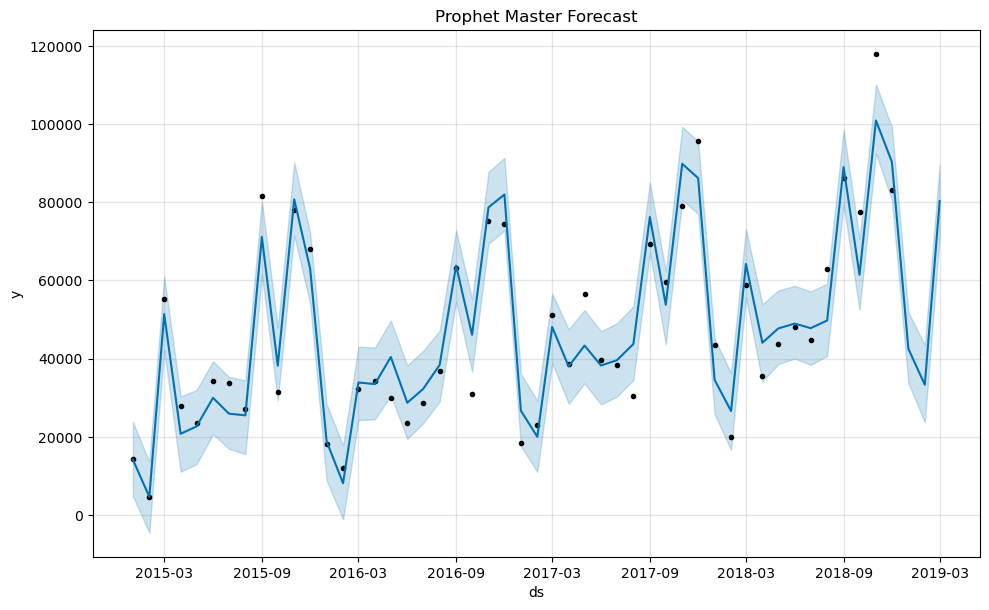

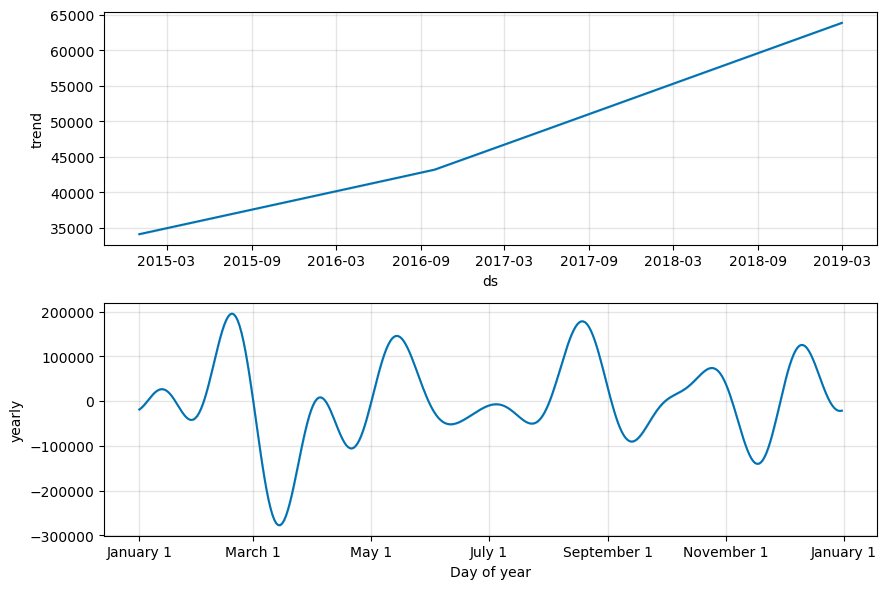

In [49]:
from prophet import Prophet

# Format dataset for Prophet engine
prophet_df = monthly_series.reset_index()
prophet_df.columns = ['ds', 'y']

# Initialize and fit model
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model_prophet.fit(prophet_df)

# Create 3-month future timeline
future = model_prophet.make_future_dataframe(periods=3, freq='MS')
forecast_prophet = model_prophet.predict(future)

# Plot interactive forecast tracking
model_prophet.plot(forecast_prophet)
plt.title("Prophet Master Forecast")
plt.show()

# Plot internal components (Trend, Yearly Seasonality)
model_prophet.plot_components(forecast_prophet)
plt.show()


# Model 3 - XGBoost (Machine Learning Approach)

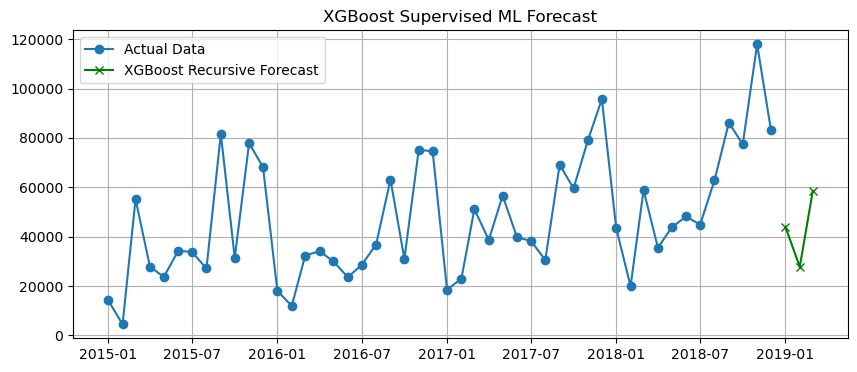

In [50]:
import xgboost as xgb

# 1. Feature Engineering
ml_df = pd.DataFrame(monthly_series)
ml_df.columns = ['Sales']

ml_df['Lag_1'] = ml_df['Sales'].shift(1)
ml_df['Lag_2'] = ml_df['Sales'].shift(2)
ml_df['Lag_3'] = ml_df['Sales'].shift(3)
ml_df['Rolling_Mean_3'] = ml_df['Sales'].shift(1).rolling(window=3).mean()
ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter

# Handle categorical 'Season' cleanly via numerical encoding
season_map = {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
ml_df['Season_Enc'] = ml_df.index.month.map(season_map)

# Drop initial empty lag buffer rows
train_data = ml_df.dropna()

# Split Features and Target
X_train = train_data[['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season_Enc']]
y_train = train_data['Sales']

# 2. Train Model
model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

# 3. Step-by-Step Multi-Period Recursive Forecast
future_dates = pd.date_range(start=monthly_series.index[-1] + pd.DateOffset(months=1), periods=3, freq='MS')
forecast_outputs = []
current_history = list(monthly_series.values)

for i in range(3):
    current_date = future_dates[i]
    
    # Calculate feature variables dynamically using shifting history
    lag1 = current_history[-1]
    lag2 = current_history[-2]
    lag3 = current_history[-3]
    roll3 = np.mean(current_history[-3:])
    m = current_date.month
    q = current_date.quarter
    s = season_map[m]
    
    # Run prediction vector
    features = pd.DataFrame([[lag1, lag2, lag3, roll3, m, q, s]], columns=X_train.columns)
    pred_val = model_xgb.predict(features)[0]
    
    forecast_outputs.append(pred_val)
    current_history.append(pred_val) # Append output value back to track ongoing shifts

xgb_forecast = pd.Series(forecast_outputs, index=future_dates)

# 4. Plot Evaluation Charts
plt.figure(figsize=(10, 4))
plt.plot(monthly_series, label='Actual Data', marker='o')
plt.plot(xgb_forecast, label='XGBoost Recursive Forecast', marker='x', color='green')
plt.title("XGBoost Supervised ML Forecast")
plt.legend()
plt.grid(True)
plt.show()


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Helper function to calculate MAPE cleanly
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 2. Extract fitted values from each model for historical evaluation
# SARIMA historical fit
sarima_fitted = results_sarima.fittedvalues

# Prophet historical fit (match timestamps with original series)
prophet_fitted = forecast_prophet.iloc[:len(monthly_series)]['yhat'].values

# XGBoost historical fit (aligned with training data)
xgb_fitted = model_xgb.predict(X_train)
y_train_actual = y_train

# 3. Calculate Error Metrics
metrics = {
    "SARIMA": [
        mean_absolute_error(monthly_series, sarima_fitted),
        np.sqrt(mean_squared_error(monthly_series, sarima_fitted)),
        mean_absolute_percentage_error(monthly_series, sarima_fitted)
    ],
    "Prophet": [
        mean_absolute_error(monthly_series, prophet_fitted),
        np.sqrt(mean_squared_error(monthly_series, prophet_fitted)),
        mean_absolute_percentage_error(monthly_series, prophet_fitted)
    ],
    "XGBoost": [
        mean_absolute_error(y_train_actual, xgb_fitted),
        np.sqrt(mean_squared_error(y_train_actual, xgb_fitted)),
        mean_absolute_percentage_error(y_train_actual, xgb_fitted)
    ]
}

# 4. Extract Future Forecast Values (Months 1, 2, and 3)
f_sarima = sarima_mean.values
f_prophet = forecast_prophet.iloc[-3:]['yhat'].values
f_xgb = xgb_forecast.values

# 5. Compile into the exact Comparison Table
comparison_data = {
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [metrics["SARIMA"][0], metrics["Prophet"][0], metrics["XGBoost"][0]],
    "RMSE": [metrics["SARIMA"][1], metrics["Prophet"][1], metrics["XGBoost"][1]],
    "MAPE (%)": [metrics["SARIMA"][2], metrics["Prophet"][2], metrics["XGBoost"][2]],
    "Forecast Month 1": [f_sarima[0], f_prophet[0], f_xgb[0]],
    "Forecast Month 2": [f_sarima[1], f_prophet[1], f_xgb[1]],
    "Forecast Month 3": [f_sarima[2], f_prophet[2], f_xgb[2]]
}

comparison_table = pd.DataFrame(comparison_data)

# Render the beautifully formatted table directly in your notebook
comparison_table.style.format({
    "MAE": "${:,.2f}", "RMSE": "${:,.2f}", "MAPE (%)": "{:.2f}%",
    "Forecast Month 1": "${:,.2f}", "Forecast Month 2": "${:,.2f}", "Forecast Month 3": "${:,.2f}"
})

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,"$14,377.16","$19,605.98",42.55%,"$43,492.28","$34,805.11","$69,907.41"
1,Prophet,"$5,751.49","$7,308.45",13.80%,"$42,548.14","$33,310.13","$80,304.67"
2,XGBoost,$361.62,$499.43,1.00%,"$44,013.30","$27,759.50","$58,472.65"


# Task 4 - Product Category & Region Level Forecasting

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observation

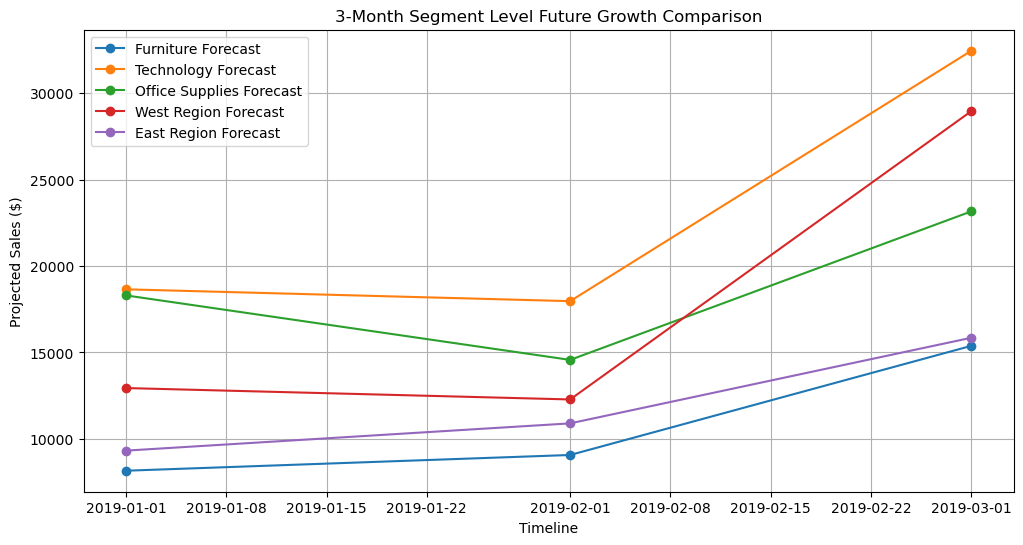

In [52]:
segments = {
    "Furniture": df[df["Category"] == "Furniture"],
    "Technology": df[df["Category"] == "Technology"],
    "Office Supplies": df[df["Category"] == "Office Supplies"],
    "West Region": df[df["Region"] == "West"],
    "East Region": df[df["Region"] == "East"]
}

forecasts = {}
future_dates = pd.date_range(start=monthly_series.index[-1] + pd.DateOffset(months=1), periods=3, freq='MS')

plt.figure(figsize=(12, 6))

for name, seg_df in segments.items():
    # Resample to continuous monthly sequence
    seg_series = seg_df.set_index("Order Date")["Sales"].resample("MS").sum()
    
    # Fit baseline SARIMA model
    model = SARIMAX(seg_series, order=(1,1,1), seasonal_order=(1,1,1,12), initialization='approximate_diffuse')
    res = model.fit(disp=False)
    
    # Predict next 3 months
    f_val = res.get_forecast(steps=3).predicted_mean
    forecasts[name] = f_val
    
    # Plot forecast segment tracks
    plt.plot(future_dates, f_val, marker='o', label=f"{name} Forecast")

plt.title("3-Month Segment Level Future Growth Comparison")
plt.xlabel("Timeline")
plt.ylabel("Projected Sales ($)")
plt.legend()
plt.grid(True)
plt.show()


# Task 5 - Anomaly Detection in Sales Data

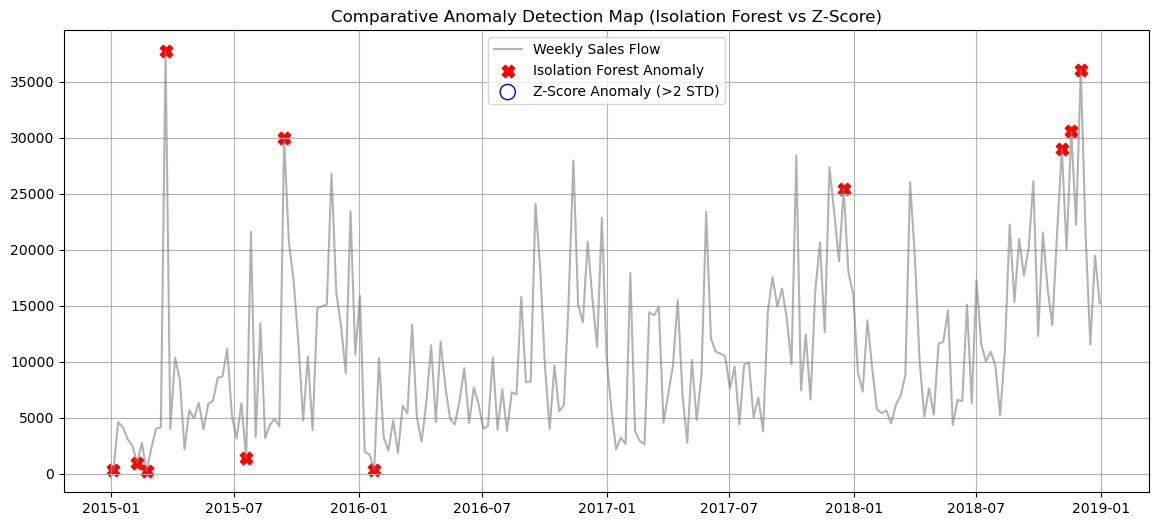

In [53]:
from sklearn.ensemble import IsolationForest
import numpy as np

# Prepare base weekly timeline dataframe
weekly_df = ts_df["Sales"].resample("W").sum().to_frame()

# 1. Isolation Forest Detection
iso = IsolationForest(contamination=0.05, random_state=42)
weekly_df['Iso_Anomaly'] = iso.fit_predict(weekly_df[['Sales']])
# Mapping: -1 is anomaly, 1 is normal cluster point

# 2. Rolling Z-Score Detection (Window = 4 weeks)
rolling_mean = weekly_df['Sales'].rolling(window=4, min_periods=1).mean()
rolling_std = weekly_df['Sales'].rolling(window=4, min_periods=1).std().fillna(0)
weekly_df['Z_Score'] = (weekly_df['Sales'] - rolling_mean) / np.where(rolling_std == 0, 1, rolling_std)
weekly_df['Z_Anomaly'] = np.where(np.abs(weekly_df['Z_Score']) > 2, -1, 1)

# 3. Comprehensive Time-Series Visualization
plt.figure(figsize=(14, 6))
plt.plot(weekly_df.index, weekly_df['Sales'], color='gray', alpha=0.6, label='Weekly Sales Flow')

# Highlight Isolation Forest findings
iso_anoms = weekly_df[weekly_df['Iso_Anomaly'] == -1]
plt.scatter(iso_anoms.index, iso_anoms['Sales'], color='red', marker='X', s=80, label='Isolation Forest Anomaly')

# Highlight Z-Score findings
z_anoms = weekly_df[weekly_df['Z_Anomaly'] == -1]
plt.scatter(z_anoms.index, z_anoms['Sales'], color='blue', facecolors='none', edgecolors='blue', s=120, label='Z-Score Anomaly (>2 STD)')

plt.title("Comparative Anomaly Detection Map (Isolation Forest vs Z-Score)")
plt.legend()
plt.grid(True)
plt.show()


# Task 6 - Product Demand Segmentation using Clustering

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


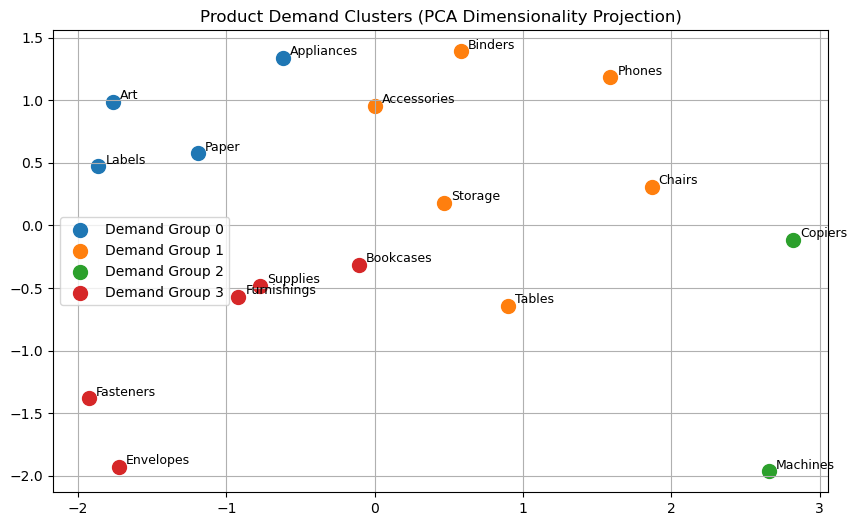

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Engineering the Sub-Category Analytics Base
# To find volatility safely, we first group by sub-category AND month, then take the standard deviation.
monthly_sub_sales = df.groupby(["Sub-Category", "Year", "Month"])["Sales"].sum().reset_index()
volatility_series = monthly_sub_sales.groupby("Sub-Category")["Sales"].std().fillna(0)

# Build the main analytics dataframe
sub_base = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Avg_Order_Value=("Sales", "mean")
)
sub_base["Volatility"] = volatility_series

# Calculate Year-over-Year Growth Rate
y2017 = df[df["Year"] == 2017].groupby("Sub-Category")["Sales"].sum()
y2018 = df[df["Year"] == 2018].groupby("Sub-Category")["Sales"].sum()
sub_base["Growth_Rate"] = ((y2018 - y2017) / y2017).fillna(0) * 100

# Normalize metric fields
scaler = StandardScaler()
scaled_feats = scaler.fit_transform(sub_base)

# 2. K-Means Engine Clustering (Setting Optimal K=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
sub_base['Cluster'] = kmeans.fit_predict(scaled_feats)

# 3. PCA Dimensionality Reduction to 2D Plot Space
pca = PCA(n_components=2)
pca_feats = pca.fit_transform(scaled_feats)
sub_base['PCA1'] = pca_feats[:, 0]
sub_base['PCA2'] = pca_feats[:, 1]

# Plotting the derived Segment Map
plt.figure(figsize=(10, 6))
for cluster_num in range(4):
    c_df = sub_base[sub_base['Cluster'] == cluster_num]
    plt.scatter(c_df['PCA1'], c_df['PCA2'], label=f"Demand Group {cluster_num}", s=100)
    for idx, row in c_df.iterrows():
        plt.annotate(idx, (row['PCA1'], row['PCA2']), xytext=(5,2), textcoords='offset points', fontsize=9)

plt.title("Product Demand Clusters (PCA Dimensionality Projection)")
plt.legend()
plt.grid(True)
plt.show()


In [59]:
import os
import matplotlib.pyplot as plt

# 1. Create the charts folder if it doesn't already exist
os.makedirs("charts", exist_ok=True)
print("📂 'charts/' directory verified/created successfully.")

# =====================================================================
# TASK 2 CHARTS
# =====================================================================
# Chart 1: Overall Monthly Sales Trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_series, marker='o', color='b', linewidth=2)
plt.title("Overall Monthly Sales Trend (4 Years)")
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")
plt.grid(True)
plt.savefig("charts/monthly_sales_trend.png", bbox_inches='tight', dpi=150)
plt.close()

# Chart 2: Time Series Decomposition
plt.rcParams['figure.figsize'] = (12, 10)
fig = decomposition.plot()
plt.suptitle("Sales Signal Decomposition (Trend, Seasonality, Noise)", fontsize=16, y=1.02)
plt.savefig("charts/time_series_decomposition.png", bbox_inches='tight', dpi=150)
plt.close()

# =====================================================================
# TASK 3 CHARTS
# =====================================================================
# Chart 3: SARIMA Forecast
plt.figure(figsize=(10, 4))
plt.plot(monthly_series, label='Actual Sales', marker='o')
plt.plot(sarima_mean, label='SARIMA 3-Month Forecast', marker='x', color='red')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title("SARIMA Sales Forecast")
plt.legend()
plt.grid(True)
plt.savefig("charts/sarima_forecast.png", bbox_inches='tight', dpi=150)
plt.close()

# Chart 4: Prophet Forecast
fig_prophet = model_prophet.plot(forecast_prophet)
plt.title("Prophet Master Forecast")
plt.savefig("charts/prophet_forecast.png", bbox_inches='tight', dpi=150)
plt.close(fig_prophet)

# Chart 5: XGBoost Forecast
plt.figure(figsize=(10, 4))
plt.plot(monthly_series, label='Actual Data', marker='o')
plt.plot(xgb_forecast, label='XGBoost Recursive Forecast', marker='x', color='green')
plt.title("XGBoost Supervised ML Forecast")
plt.legend()
plt.grid(True)
plt.savefig("charts/xgboost_forecast.png", bbox_inches='tight', dpi=150)
plt.close()

# =====================================================================
# TASK 5 & 6 CHARTS
# =====================================================================
# Chart 6: Anomaly Detection Map
plt.figure(figsize=(14, 6))
plt.plot(weekly_df.index, weekly_df['Sales'], color='gray', alpha=0.6, label='Weekly Sales Flow')
iso_anoms = weekly_df[weekly_df['Iso_Anomaly'] == -1]
plt.scatter(iso_anoms.index, iso_anoms['Sales'], color='red', marker='X', s=80, label='Isolation Forest Anomaly')
z_anoms = weekly_df[weekly_df['Z_Anomaly'] == -1]
plt.scatter(z_anoms.index, z_anoms['Sales'], color='blue', facecolors='none', edgecolors='blue', s=120, label='Z-Score Anomaly (>2 STD)')
plt.title("Comparative Anomaly Detection Map (Isolation Forest vs Z-Score)")
plt.legend()
plt.grid(True)
plt.savefig("charts/anomaly_detection_map.png", bbox_inches='tight', dpi=150)
plt.close()

# Chart 7: Product Demand Clusters (PCA)
plt.figure(figsize=(10, 6))
for cluster_num in range(4):
    c_df = sub_base[sub_base['Cluster'] == cluster_num]
    plt.scatter(c_df['PCA1'], c_df['PCA2'], label=f"Demand Group {cluster_num}", s=100)
    for idx, row in c_df.iterrows():
        plt.annotate(idx, (row['PCA1'], row['PCA2']), xytext=(5,2), textcoords='offset points', fontsize=9)
plt.title("Product Demand Clusters (PCA Dimensionality Projection)")
plt.legend()
plt.grid(True)
plt.savefig("charts/product_demand_clusters.png", bbox_inches='tight', dpi=150)
plt.close()

print("🚀 Success! All 7 project charts have been exported to the 'charts/' folder.")


📂 'charts/' directory verified/created successfully.
🚀 Success! All 7 project charts have been exported to the 'charts/' folder.
